Using Colab cache for faster access to the 'fifa-22-complete-player-dataset' dataset.


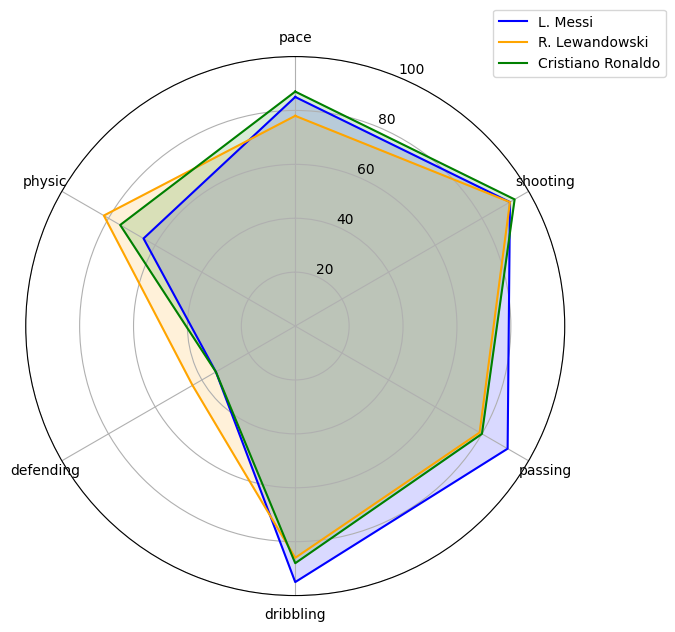

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "stefanoleone992/fifa-22-complete-player-dataset",
    "players_22.csv",
    pandas_kwargs={"low_memory": False}
)
kolumny = ['Name', 'Crossing', 'Finishing', 'Dribbling', 'LongPassing', 'Stamina', 'Strength', 'Agility']

def rysuj_radar_fifa(dane_wejsciowe):
    pilkarze = dane_wejsciowe.iloc[:, 0].tolist()
    cechy = dane_wejsciowe.columns[1:].tolist()

    katy = np.linspace(0, 2 * np.pi, len(cechy), endpoint=False).tolist()
    katy += katy[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    paleta_kolorow = ['blue', 'orange', 'green', 'red', 'purple', 'magenta']

    for i, nazwa in enumerate(pilkarze):
        wiersz = dane_wejsciowe[dane_wejsciowe.iloc[:, 0] == nazwa]
        statystyki = wiersz.iloc[:, 1:].values.ravel().tolist()
        statystyki += statystyki[:1]

        kolor = paleta_kolorow[i % len(paleta_kolorow)]

        ax.plot(katy, statystyki, label=nazwa, color=kolor)
        ax.fill(katy, statystyki, color=kolor, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(katy[:-1]), cechy)
    ax.set_ylim(0, 100)

    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

rysuj_radar_fifa(dane_testowe)